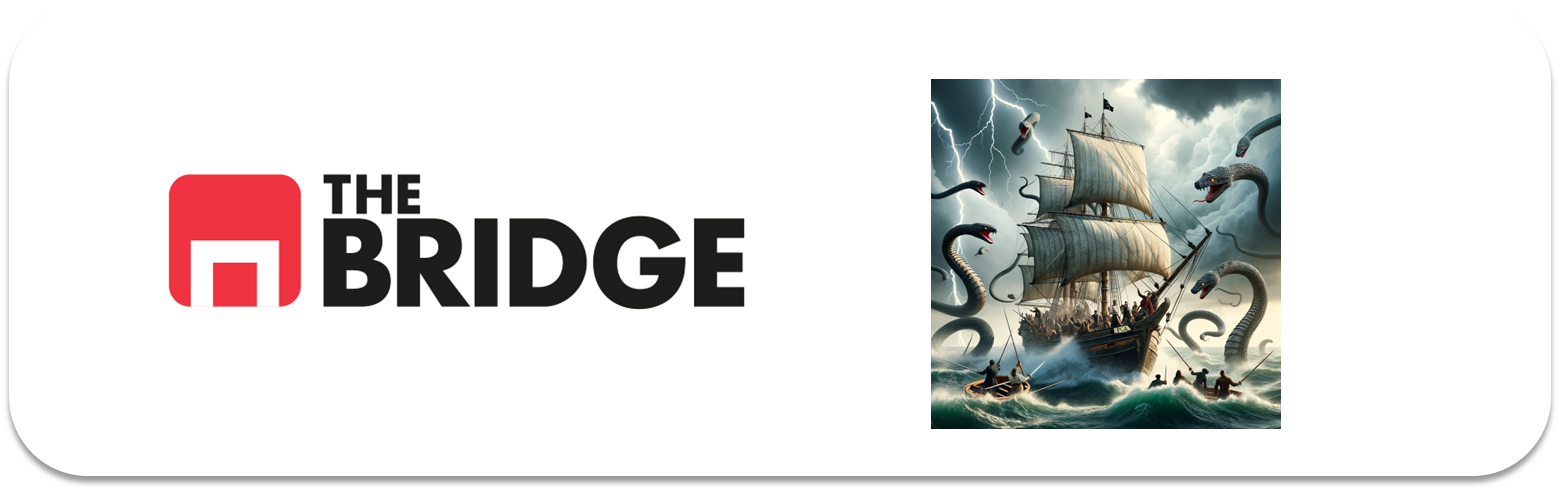

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

Problema:  
Imágenes comprimidas --> Procesamiento compromido  
Envio de imágenes --> Imágenes descomprimidas --> Procesamiento descomprimido --> Análisis de imágenes  
Análisis --> Modelo de clasificación de imagen

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
# Paquetes y módulos de base
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Cargar dataset
from sklearn.datasets import fetch_olivetti_faces

# Modelos
from sklearn.model_selection import train_test_split, cross_val_score
# Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score

# PCA
from sklearn.decomposition import PCA

# Otros
import random

# Control de warnings
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [3]:
# from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
df_olivetti = pd.DataFrame(olivetti.data, columns = [f"pixel_{i}" for i in range(4096)])
df_olivetti["cara"] = olivetti.target
df_olivetti_back = df_olivetti.copy()  # Copia de seguridad
print(df_olivetti.size)
df_olivetti.head()


1638800


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11,pixel_12,pixel_13,pixel_14,pixel_15,pixel_16,pixel_17,pixel_18,pixel_19,pixel_20,pixel_21,pixel_22,pixel_23,pixel_24,pixel_25,pixel_26,pixel_27,pixel_28,pixel_29,pixel_30,pixel_31,pixel_32,pixel_33,pixel_34,pixel_35,pixel_36,pixel_37,pixel_38,pixel_39,...,pixel_4057,pixel_4058,pixel_4059,pixel_4060,pixel_4061,pixel_4062,pixel_4063,pixel_4064,pixel_4065,pixel_4066,pixel_4067,pixel_4068,pixel_4069,pixel_4070,pixel_4071,pixel_4072,pixel_4073,pixel_4074,pixel_4075,pixel_4076,pixel_4077,pixel_4078,pixel_4079,pixel_4080,pixel_4081,pixel_4082,pixel_4083,pixel_4084,pixel_4085,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,cara
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,0.702479,0.698347,0.694215,0.698347,0.690083,0.694215,0.690083,0.698347,0.702479,0.702479,0.698347,0.706612,0.710744,0.719008,0.727273,0.756198,0.772727,0.776860,0.776860,0.756198,0.760331,0.780992,0.760331,0.768595,0.756198,0.739669,0.743802,0.739669,0.743802,0.719008,...,0.752066,0.694215,0.690083,0.681818,0.681818,0.657025,0.648760,0.636364,0.632231,0.636364,0.623967,0.619835,0.644628,0.681818,0.685950,0.677686,0.681818,0.673554,0.665289,0.632231,0.582645,0.541322,0.537190,0.537190,0.553719,0.570248,0.611570,0.632231,0.657025,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,0.710744,0.698347,0.702479,0.706612,0.706612,0.714876,0.714876,0.706612,0.698347,0.714876,0.698347,0.723140,0.731405,0.743802,0.756198,0.772727,0.768595,0.785124,0.764463,0.756198,0.731405,0.743802,0.735537,0.719008,0.706612,0.714876,0.719008,0.710744,0.710744,0.706612,...,0.661157,0.652893,0.628099,0.632231,0.644628,0.640496,0.628099,0.632231,0.636364,0.628099,0.619835,0.619835,0.603306,0.590909,0.561983,0.516529,0.533058,0.578512,0.570248,0.561983,0.557851,0.545455,0.111570,0.095041,0.152893,0.152893,0.128099,0.136364,0.132231,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,0.702479,0.706612,0.706612,0.714876,0.710744,0.706612,0.706612,0.706612,0.723140,0.719008,0.719008,0.710744,0.710744,0.752066,0.756198,0.764463,0.785124,0.797521,0.838843,0.826446,0.842975,0.847107,0.830579,0.818182,0.793388,0.768595,0.760331,0.756198,0.739669,0.710744,...,0.714876,0.706612,0.685950,0.665289,0.652893,0.644628,0.636364,0.623967,0.636364,0.657025,0.644628,0.677686,0.681818,0.690083,0.690083,0.690083,0.681818,0.661157,0.652893,0.636364,0.586777,0.545455,0.570248,0.607438,0.603306,0.595041,0.578512,0.607438,0.413223,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,0.537190,0.566116,0.574380,0.586777,0.611570,0.632231,0.640496,0.657025,0.673554,0.694215,0.702479,0.719008,0.727273,0.719008,0.723140,0.710744,0.739669,0.747934,0.756198,0.756198,0.764463,0.772727,0.785124,0.785124,0.805785,0.818182,0.805785,0.809917,0.793388,0.789256,...,0.442149,0.479339,0.512397,0.537190,0.557851,0.566116,0.586777,0.586777,0.615702,0.632231,0.661157,0.681818,0.673554,0.714876,0.710744,0.706612,0.690083,0.681818,0.623967,0.615702,0.586777,0.582645,0.578512,0.590909,0.590909,0.611570,0.628099,0.644628,0.657025,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,0.739669,0.739669,0.764463,0.756198,0.764463,0.785124,0.793388,0.797521,0.814050,0.809917,0.809917,0.818182,0.830579,0.830579,0.842975,0.838843,0.838843,0.838843,0.830579,0.818182,0.805785,0.801653,0.797521,0.793388,0.793388,0.785124,0.797521,

Como las etiquetas están ordenadas, las desordenamos:  
1. Comprobamos la distribución del target  
2. Visualizamos una imagen  
3. Desordenamos el dataset con el método .sample de los DataFrame

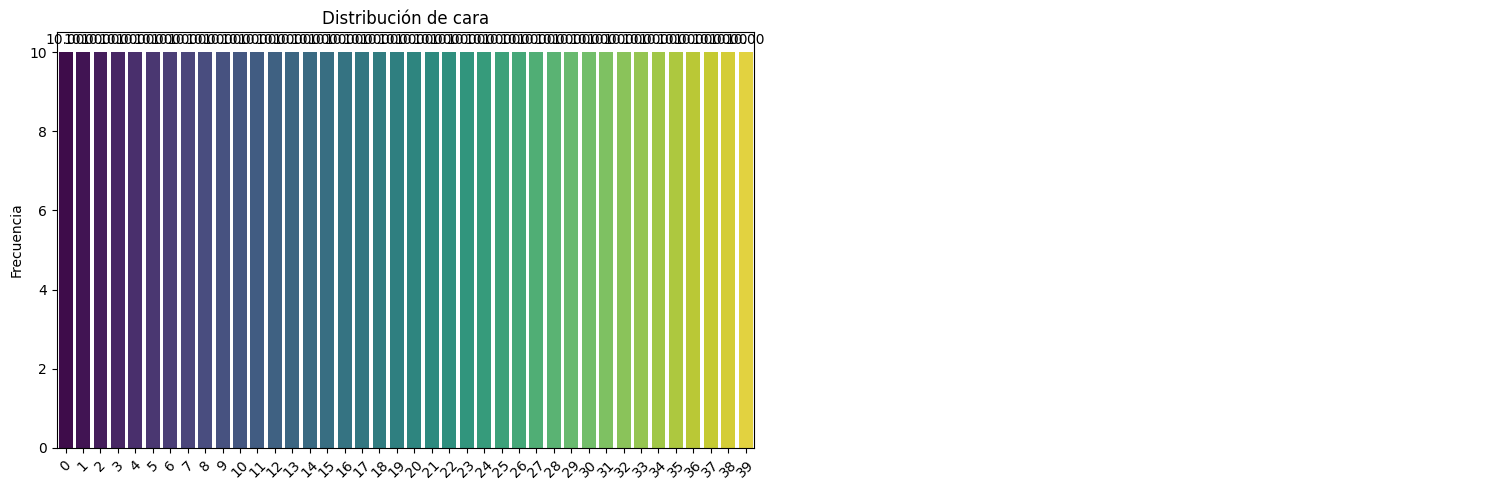

In [4]:
# import bootcampviztools as bt
bt.pinta_distribucion_categoricas(df_olivetti, ["cara"], mostrar_valores=True)

In [5]:
df_olivetti["cara"].value_counts(normalize=True)

cara
0     0.025
1     0.025
2     0.025
3     0.025
4     0.025
5     0.025
6     0.025
7     0.025
8     0.025
9     0.025
10    0.025
11    0.025
12    0.025
13    0.025
14    0.025
15    0.025
16    0.025
17    0.025
18    0.025
19    0.025
20    0.025
21    0.025
22    0.025
23    0.025
24    0.025
25    0.025
26    0.025
27    0.025
28    0.025
29    0.025
30    0.025
31    0.025
32    0.025
33    0.025
34    0.025
35    0.025
36    0.025
37    0.025
38    0.025
39    0.025
Name: proportion, dtype: float64

Text(0.5, 1.0, '0')

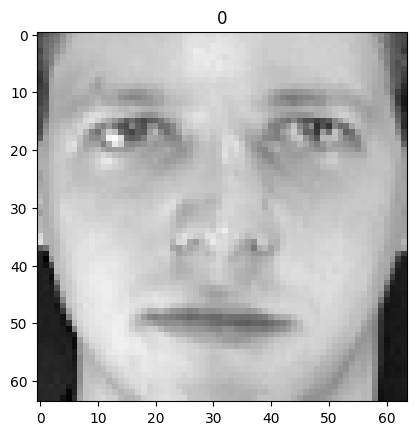

In [6]:
image_sample = df_olivetti.iloc[0].drop("cara").values.reshape(64,64)
plt.imshow(image_sample, cmap='gray');
plt.title(df_olivetti["cara"].iloc[0])

Aclaraciones:  
```python
df_olivetti.iloc[0].drop("cara").values.reshape(64,64)
```
.iloc[0] — accede a la primera fila por índice numérico  
.drop()  --> quitamos la etiqueta  
.values — convierte la fila a un array de NumPy antes del reshape

In [7]:
df_olivetti = df_olivetti.sample(len(df_olivetti), random_state=42)  # Importante random_state para mantener el orden establecido


In [8]:
df_olivetti["cara"].tail()

71      7
106    10
270    27
348    34
102    10
Name: cara, dtype: int64

In [9]:
# from sklearn.model_selection import train_test_split, cross_val_score
train_set, test_set = train_test_split(df_olivetti,
                                       test_size = 85,
                                        stratify=df_olivetti["cara"],
                                        random_state= 42)

print(train_set.shape)
print(test_set.shape)


(315, 4097)
(85, 4097)


In [10]:
train_set["cara"].value_counts(normalize=True)

cara
35    0.025397
19    0.025397
15    0.025397
33    0.025397
39    0.025397
12    0.025397
11    0.025397
10    0.025397
24    0.025397
34    0.025397
6     0.025397
26    0.025397
25    0.025397
8     0.025397
13    0.025397
37    0.025397
27    0.025397
31    0.025397
30    0.025397
32    0.025397
1     0.025397
9     0.025397
17    0.025397
21    0.025397
29    0.025397
3     0.025397
22    0.025397
0     0.025397
23    0.025397
5     0.025397
16    0.025397
36    0.025397
4     0.025397
2     0.025397
18    0.025397
28    0.022222
38    0.022222
7     0.022222
20    0.022222
14    0.022222
Name: proportion, dtype: float64

Como ya he analizado la distribución del target, lo único que voy a hacer con el resto de features es comprobar sus valores para decidir si normalizamos y escalamos. Siendo imágenes no hace falta analizar más.

In [11]:
X_train = train_set.drop("cara", axis = 1)
y_train = train_set["cara"]

X_test = test_set.drop("cara", axis = 1)
y_test = test_set["cara"]

In [12]:
print(np.min(X_train.describe().T["min"]))
print(np.max(X_train.describe().T["max"]))

0.0
1.0


In [13]:
print(X_train.describe().loc[['mean', 'std']])

       pixel_0   pixel_1   pixel_2  ...  pixel_4093  pixel_4094  pixel_4095
mean  0.400092  0.432559  0.476374  ...    0.324413    0.314246    0.311924
std   0.178708  0.187804  0.192290  ...    0.193197    0.187526    0.184530

[2 rows x 4096 columns]


Según los valores no tenemos que tratar los datos para el modelo

In [14]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score
lr_base = LogisticRegression(max_iter = 1000)

baseline_accuracy = np.mean(cross_val_score(lr_base, X_train, y_train, scoring = "balanced_accuracy", cv = 5))
print("Baseline, balanced_accuracy:", baseline_accuracy)



Baseline, balanced_accuracy: 0.97


In [15]:
# from sklearn.metrics import classification_report
lr_base.fit(X_train, y_train) # Tengo que hacer fit para luego poder realizar el predict
print(classification_report(y_test, 
                            lr_base.predict(X_test)))

test_accuracy_baseline = classification_report(y_test,lr_base.predict(X_test),output_dict=True)["accuracy"]
print(test_accuracy_baseline)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       1.00    

In [16]:
recall_medio = recall_score(y_test, lr_base.predict(X_test), average = "macro")
recall_medio

0.9625

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [15]:
# from sklearn.decomposition import PCA
 
pca_ml = PCA() # 1
pca_ml.fit(X_train)
X_train_pca = pca_ml.transform(X_train)
X_test_pca = pca_ml.transform(X_test)

In [16]:
tam_inicial = X_train.size
tam_compressed = X_train_pca.size
factor_compresion =(1 - tam_compressed/tam_inicial)*100.0  # Lo que queda fuera
print(f"factor de comprension: {(1 - tam_compressed/tam_inicial)*100.0}%")

factor de comprension: 92.3095703125%


In [17]:
compresion = (tam_compressed / tam_inicial) * 100 # Lo que se conserva
print(compresion)

7.6904296875


In [18]:
pca =  PCA() # 1
compresion_pca = (tam_compressed / tam_inicial) * 100
pca_range = [8, 25, 50, 75, 102] # El número de features del dataset entre un 2% - 2.5%
factor_compresion =[]
for n in pca_range:
    pca_ml = PCA(n_components=n)
    X_train_pca = pca_ml.fit_transform(X_train)
    factor_com = (X_train_pca.size / X_train.size) * 100
    factor_compresion.append(round(factor_com,2))
    varianza = pca_ml.explained_variance_ratio_.sum() * 100
    print(f"n={n:>3} | compresión: {factor_com:.2f}% | varianza explicada: {varianza:.1f}%")

n=  8 | compresión: 0.20% | varianza explicada: 61.9%
n= 25 | compresión: 0.61% | varianza explicada: 79.7%
n= 50 | compresión: 1.22% | varianza explicada: 87.9%
n= 75 | compresión: 1.83% | varianza explicada: 91.8%
n=102 | compresión: 2.49% | varianza explicada: 94.4%


In [19]:
lr_base = LogisticRegression(max_iter = 1000, class_weight= "balanced")
scores_train= []
pca_range = [8, 25, 50, 75, 102]
for n in pca_range:
    pca_ml = PCA(n_components=n)
    X_train_pca = pca_ml.fit_transform(X_train)
    score = np.mean(cross_val_score(lr_base, X_train_pca, y_train, scoring = "balanced_accuracy", cv = 5))
    scores_train.append(round(score, 4))

print(scores_train)

[np.float64(0.7825), np.float64(0.96), np.float64(0.9725), np.float64(0.9725), np.float64(0.97)]


In [20]:
pca_range = [8, 25, 50, 75, 102]
for n in pca_range:
    pca_ml = PCA(n_components=n)
    X_train_pca = pca_ml.fit_transform(X_train)
    X_test_pca = pca_ml.transform(X_test)
    lr_pca = lr_base.fit(X_train_pca, y_train)
    print(f"Para PC{n} Reporte Clasificación:","\n", classification_report(y_test, lr_pca.predict(X_test_pca)))

Para PC8 Reporte Clasificación: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       0.33      0.50      0.40         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       0.67      1.00      0.80         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       0.50      0.50      0.50         2
          16       0.00      0.00      0.00    

In [21]:
scores_test = []
pca_range = [8, 25, 50, 75, 102]
for n in pca_range:
    pca_ml = PCA(n_components=n)
    X_train_pca = pca_ml.fit_transform(X_train)
    X_test_pca = pca_ml.transform(X_test)
    lr_pca = lr_base.fit(X_train_pca, y_train)
    report = classification_report(y_test, lr_pca.predict(X_test_pca), output_dict=True)
    scores_test.append(report['accuracy'])

In [22]:
scores_test

[0.8588235294117647,
 0.9764705882352941,
 0.9764705882352941,
 0.9764705882352941,
 0.9764705882352941]

In [23]:
diferencia_train = baseline_accuracy
diferencia_test = test_accuracy_baseline

df_resultados = pd.DataFrame({
    "factor_compresion": factor_compresion
    ,"scores_train_PCA": scores_train,
     "scores_test_PCA": scores_test,
     
     }, index=pca_range)
df_resultados

,factor_compresion,scores_train_PCA,scores_test_PCA
8,0.20,0.7825,0.858824
25,0.61,0.9600,0.976471
50,1.22,0.9725,0.976471
75,1.83,0.9725,0.976471
102,2.49,0.9700,0.976471


In [24]:
df_resultados['diferencia_train_basel'] = df_resultados['scores_train_PCA'] - diferencia_train
df_resultados['diferencia_test_basel'] = df_resultados['scores_test_PCA'] - diferencia_test
df_resultados

,factor_compresion,scores_train_PCA,scores_test_PCA,diferencia_train_basel,diferencia_test_basel
8,0.20,0.7825,0.858824,-0.1875,-0.105882
25,0.61,0.9600,0.976471,-0.0100,0.011765
50,1.22,0.9725,0.976471,0.0025,0.011765
75,1.83,0.9725,0.976471,0.0025,0.011765
102,2.49,0.9700,0.976471,0.0000,0.011765


Me quedo con __75 componentes principales__.

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [37]:
pca_range = np.arange(0.001 , 0.010, 0.002)
pca_range

array([0.001, 0.003, 0.005, 0.007, 0.009])

In [38]:
round(len(X_train.columns) * 0.001)

4

In [39]:
comp = np.arange(0.001 , 0.01, 0.002)
factor_comp = []
pca_range = []
accuracy_train = []
accuracy_test =[]
for n in comp:
    x = round(len(X_train.columns) * n)
    pca_range.append(x)
    pca_ml = PCA(n_components=x)
    X_train_pca = pca_ml.fit_transform(X_train) # Aplico PCA a train
    X_test_pca = pca_ml.transform(X_test)       # Aplico PCA a test

    # Descompresión de train y test
    X_train_unzipped = pca_ml.inverse_transform(X_train_pca) 
    X_test_unzipped = pca_ml.inverse_transform(X_test_pca)

    # Modelo instanciado en el ejercicio anterior
    # lr_base = LogisticRegression(max_iter = 1000, class_weight= "balanced")
    lr_pca = lr_base.fit(X_train_unzipped, y_train)  # Entreno el modelo
    # calculo accuracy y lo guardo
    score = np.mean(cross_val_score(lr_base, X_train_unzipped, y_train, scoring = "balanced_accuracy", cv = 5))
    accuracy_train.append(round(score, 4))

     # Calculo el factor de compresión y los guardo en una lista
    factor_com = (X_train_pca.size / X_train.size) * 100 
    factor_comp.append(round(factor_com,4))
    # Calculo Accuracy de test y los guardo en una lista
    report_test_unzipped = classification_report(y_test, lr_pca.predict(X_test_unzipped),output_dict=True)
    accuracy_test.append(round(report_test_unzipped["accuracy"],4))



In [46]:
df_resultado = pd.DataFrame({
    "factor_compresion": factor_comp
    ,"accuracy_train_PCA_unzipped": accuracy_train,
     "accuracy_test_PCA_unzipped": accuracy_test,
     
     }, index=pca_range)

df_resultado

,factor_compresion,accuracy_train_PCA_unzipped,accuracy_test_PCA_unzipped
4,0.0977,0.5025,0.4588
12,0.2930,0.8800,0.9059
20,0.4883,0.9475,0.9765
29,0.7080,0.9675,0.9647
37,0.9033,0.9675,0.9647


Nos quedamos con 20 PCs (componentes principales).  
Accuracy train 0.9475.  
Accuracy test 0.9765.  
Las dos métricas muy cercanas a las de baseline.

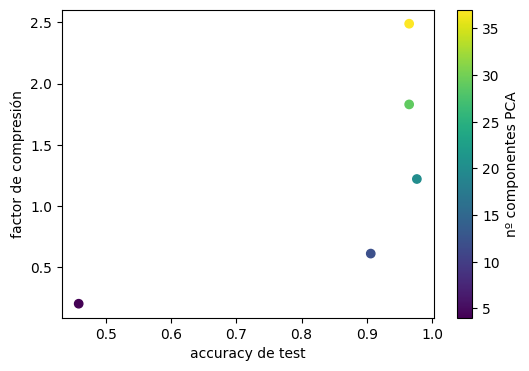

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.scatter(x = accuracy_test,  y = factor_compresion, c=pca_range)
ax.set_xlabel('accuracy de test')
ax.set_ylabel('factor de compresión')
plt.colorbar(ax.collections[0], ax=ax, label='nº componentes PCA')
plt.show();

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercera parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas caras con claridad.

In [56]:
pca = PCA(75) 
converted_data = pca.fit_transform(df_olivetti.drop("cara",axis=1))
print(converted_data.shape)

(400, 75)


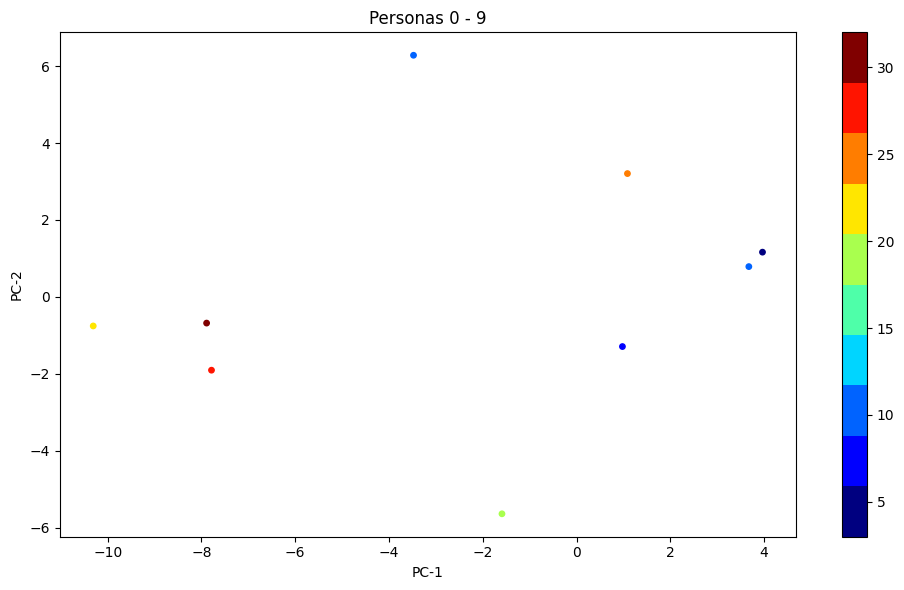

In [68]:
plt.figure(figsize = (10,6))
c_map = plt.cm.get_cmap('jet', 10)
plt.scatter(converted_data[0:9, 0],  # La primera PC
            converted_data[0:9, 1],  # La segunda PC
            s = 15,
            cmap = c_map ,
            c = df_olivetti["cara"].iloc[0:9])


plt.colorbar()
plt.title('Personas 0 - 9')
plt.xlabel('PC-1') , plt.ylabel('PC-2')
plt.tight_layout()
plt.show();


PC_4:


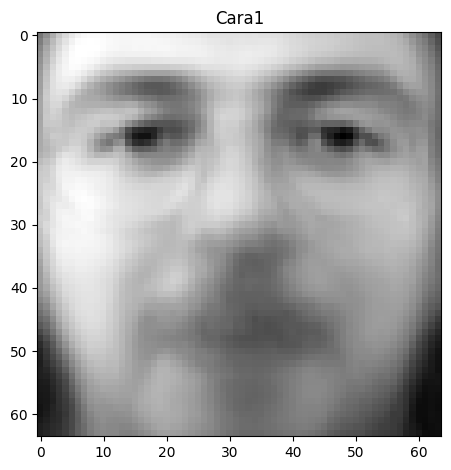

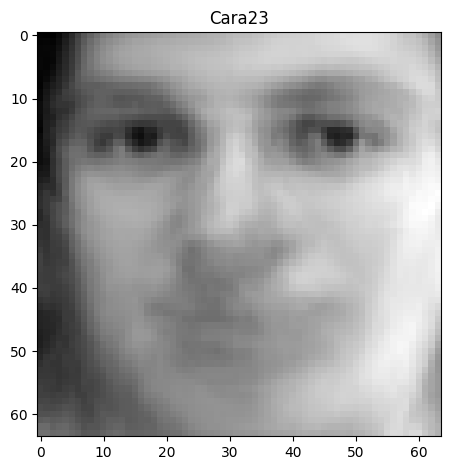

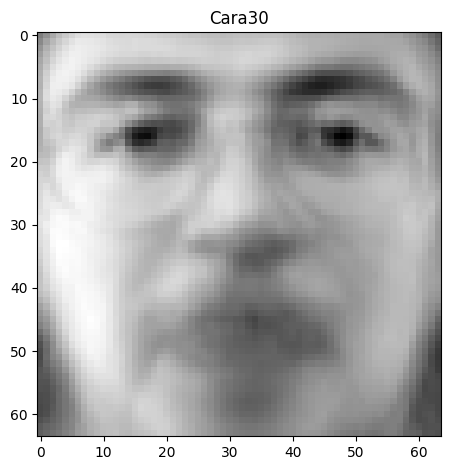

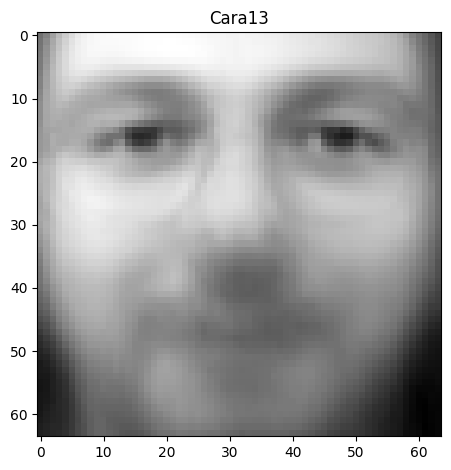

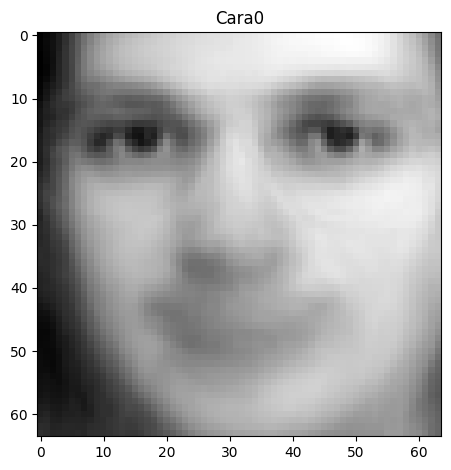

PC_12:


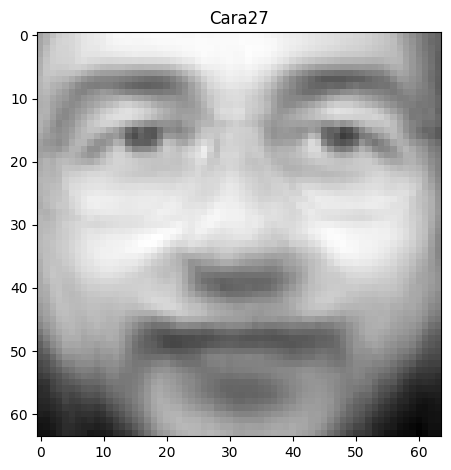

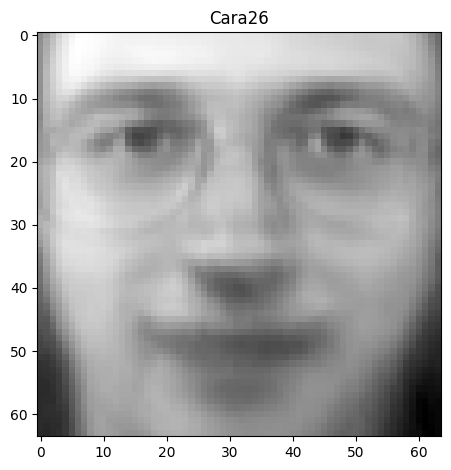

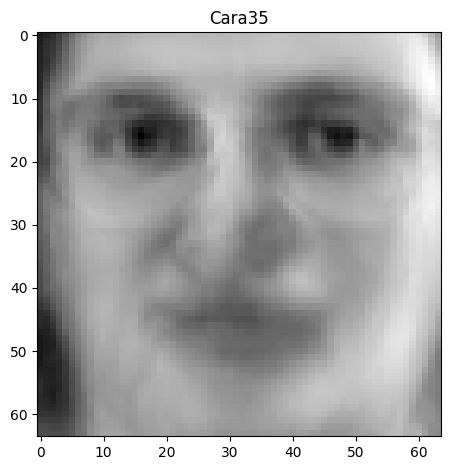

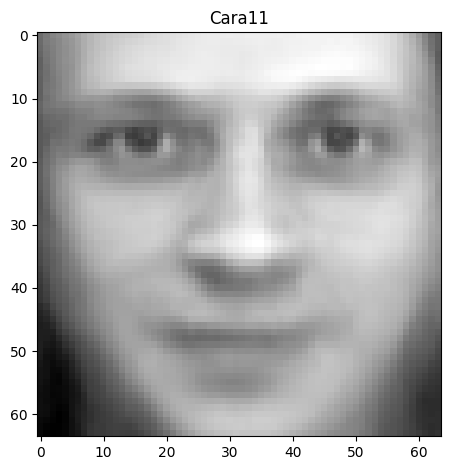

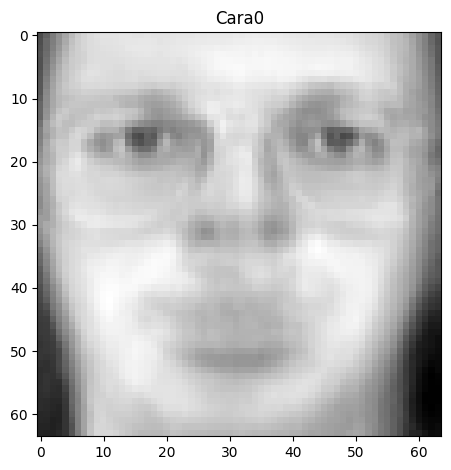

PC_20:


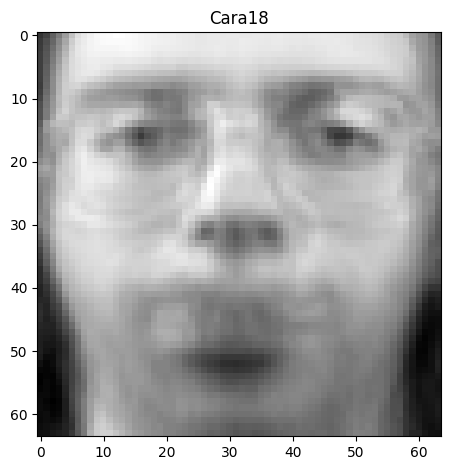

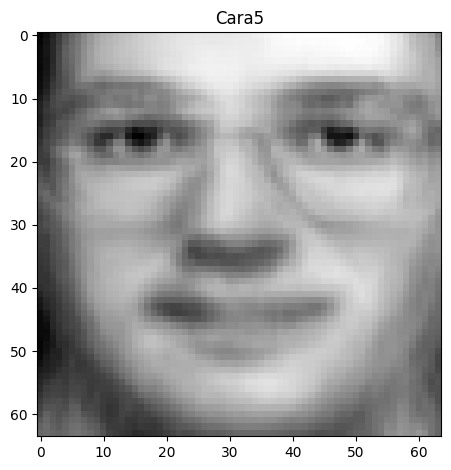

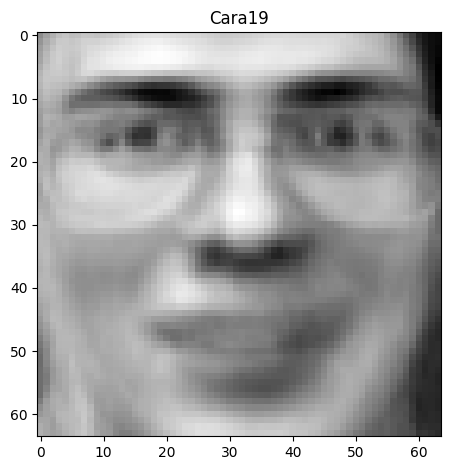

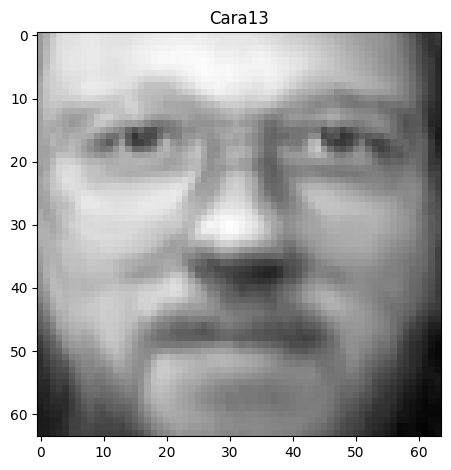

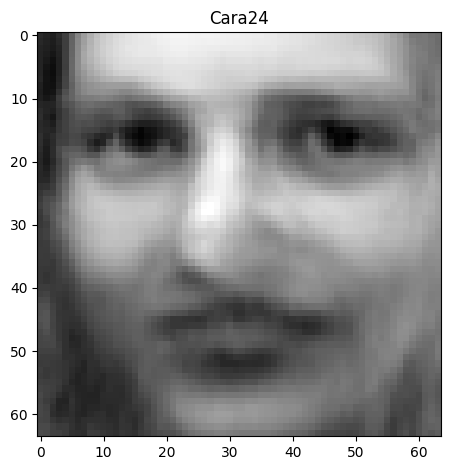

PC_29:


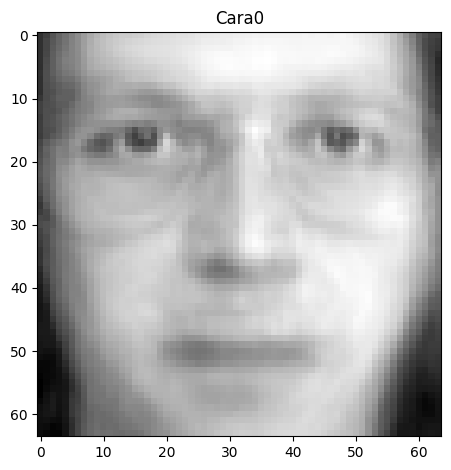

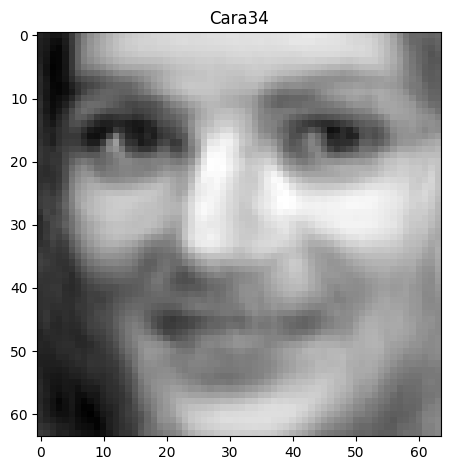

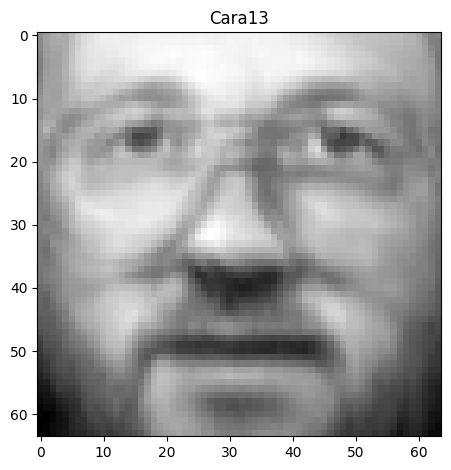

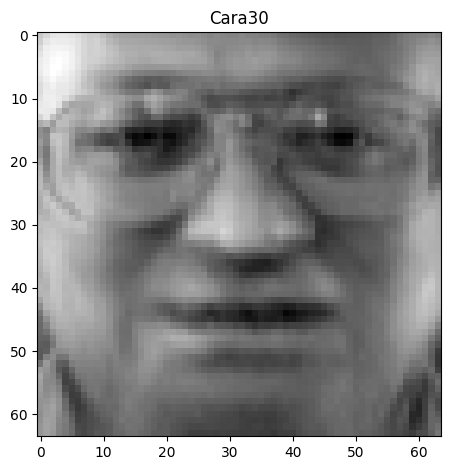

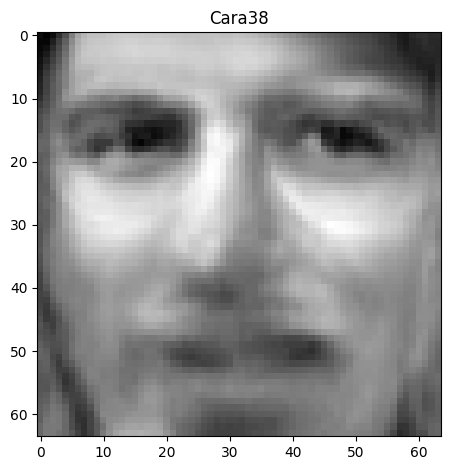

PC_37:


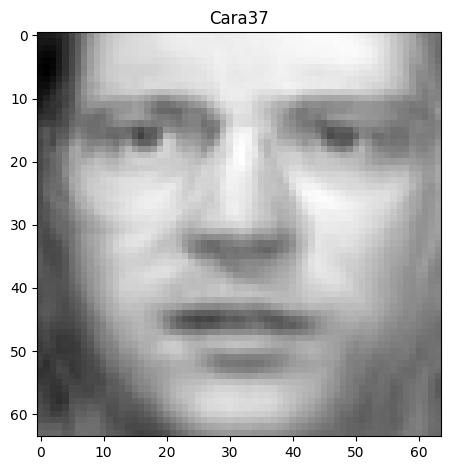

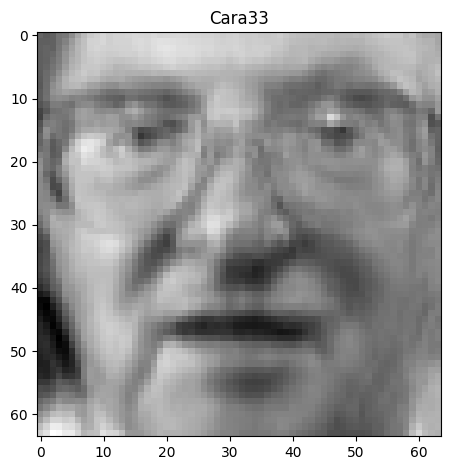

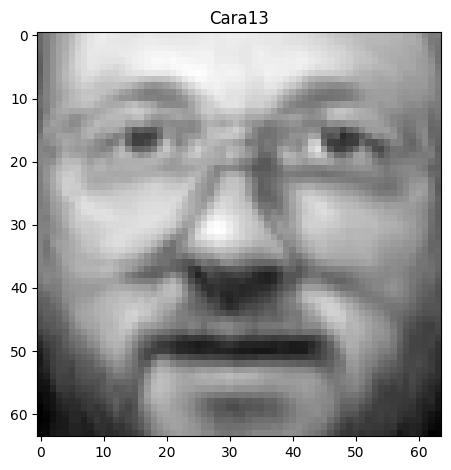

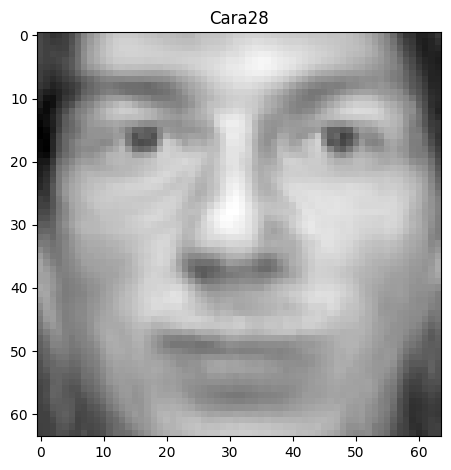

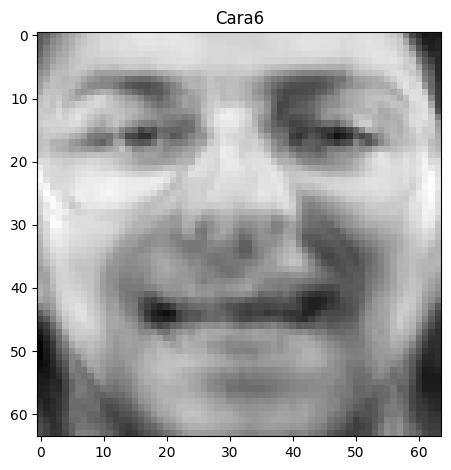

PC_150:


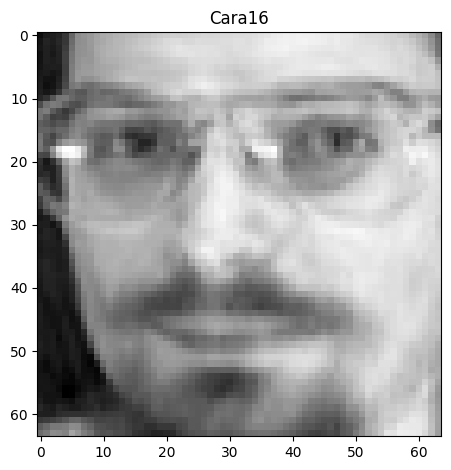

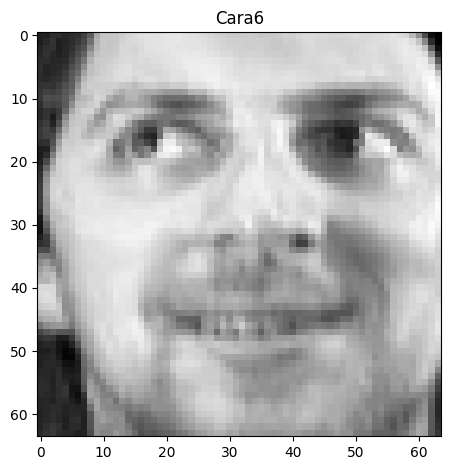

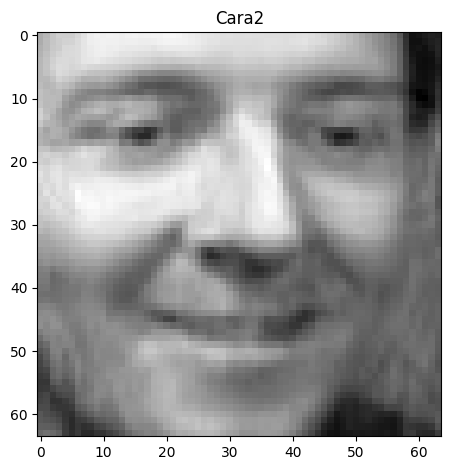

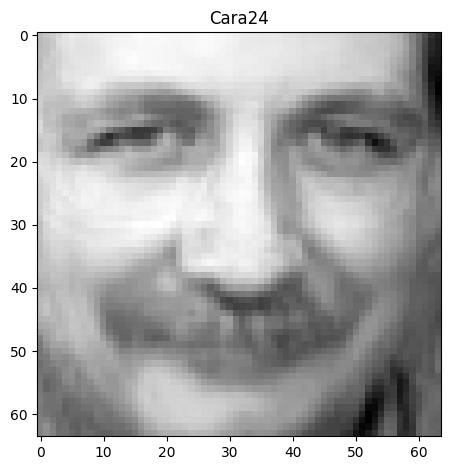

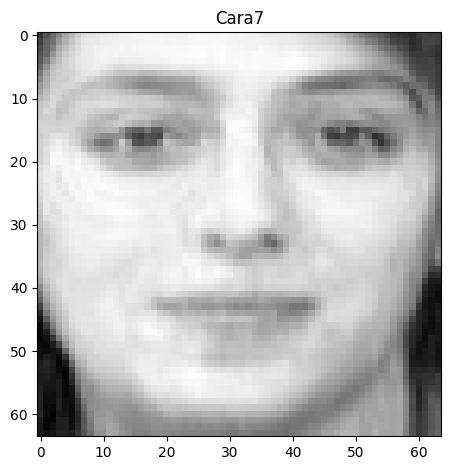

PC_320:


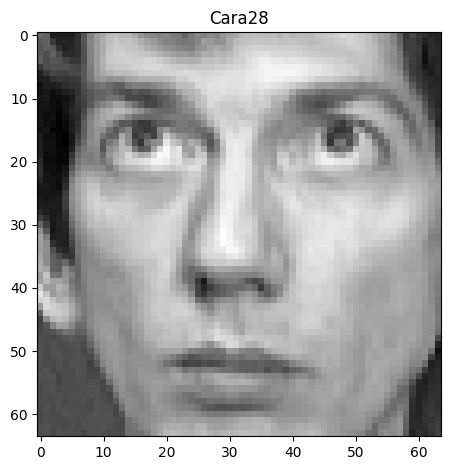

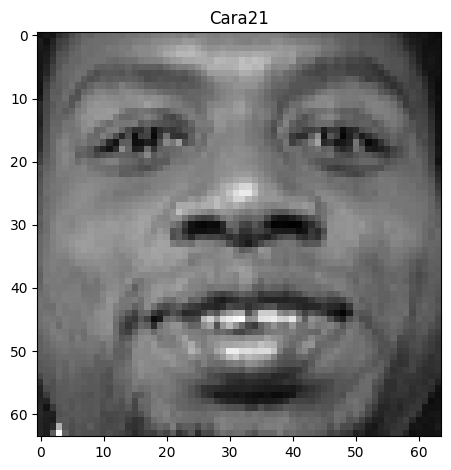

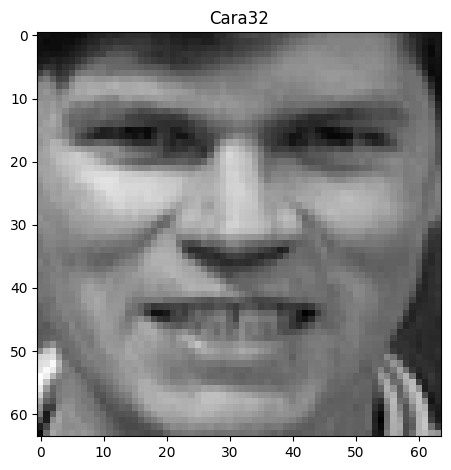

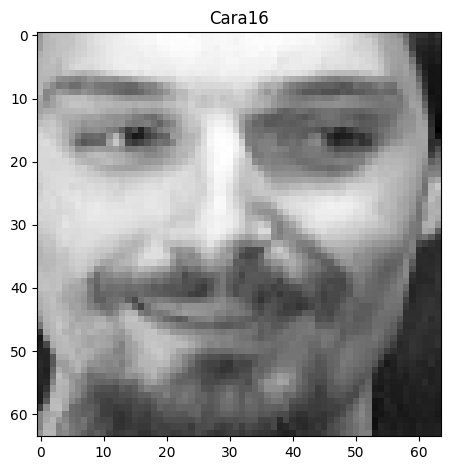

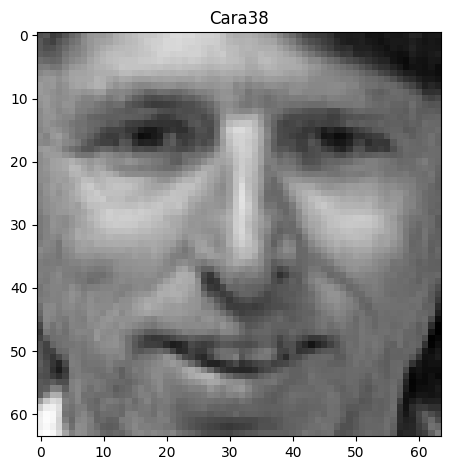

In [ ]:
# import random
pca_range = [4, 12, 20, 29, 37, 150, 320]
for n in pca_range:
    print(f"PC_{n}:")
    pca = PCA(n) 
    converted_data = pca.fit_transform(df_olivetti.drop("cara",axis=1))
    reconverted_data = pca.inverse_transform(converted_data)
    for i in random.sample(range(0, 400), 5):
        image_sample = reconverted_data[i,:].reshape(64,64)
        labels = df_olivetti["cara"].iloc[i]
        plt.imshow(image_sample, cmap='gray')
        plt.title(f"Cara{labels}")
        plt.tight_layout()
        plt.show();